<style>
/* Paper-style layout for both Jupyter and nbconvert HTML. */
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# Brownian Quadratic Variation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
PURPLE = "#8E6C8A"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def coarse_increments(fine_increments, level):
    fine_increments = np.asarray(fine_increments)
    fine_count = len(fine_increments)
    fine_level = int(np.log2(fine_count))
    if fine_count != 2**fine_level:
        raise ValueError("The fine grid must contain a power-of-two number of intervals.")
    if level < 0 or level > fine_level:
        raise ValueError("The requested dyadic level is outside the fine grid.")
    block_size = 2 ** (fine_level - level)
    return fine_increments.reshape(2**level, block_size).sum(axis=1)


def integrated_variance_curve(t, base=0.7, amplitude=0.45):
    t = np.asarray(t)
    return (
        (base**2 + 0.5 * amplitude**2) * t
        + base * amplitude / np.pi * (1.0 - np.cos(2.0 * np.pi * t))
        - amplitude**2 / (8.0 * np.pi) * np.sin(4.0 * np.pi * t)
    )

## 1. Quadratic variation is a limit of partition sums

For a partition $P=\{0=t_0<\cdots<t_N=T\}$, define its mesh and the realized quadratic variation of a process $X$ by

$$
\mu(P)=\max_{1\leq i\leq N}(t_i-t_{i-1}),
\qquad
Q_P(X)=\sum_{i=1}^N(X_{t_i}-X_{t_{i-1}})^2.
$$

Following the course notation, a process $Z$ is the quadratic variation of $X$ if, for every $t>0$ and every sequence of partitions $(P_n)$ of $[0,t]$ with $\mu(P_n)\to0$,

$$
Q_{P_n}(X)\xrightarrow{P}Z_t.
$$

We then write $\langle X\rangle_t=Z_t$. The finite sum $Q_P(X)$ is an approximation; $\langle X\rangle_t$ denotes its limit in probability.

For Brownian motion on a deterministic partition,

$$
E[Q_P(B)]=T,
\qquad
\operatorname{Var}(Q_P(B))
=2\sum_{i=1}^N(t_i-t_{i-1})^2
\leq2T\mu(P).
$$

Hence $Q_P(B)\to T$ in $L^2$, and therefore in probability. On a uniform partition with $N$ intervals,

$$
\frac{N}{T}Q_N(B)\sim\chi_N^2,
\qquad
\operatorname{RMSE}(Q_N(B),T)=\frac{\sqrt{2}\,T}{\sqrt N}.
$$

 N      empirical mean      empirical RMSE      exact RMSE
  8          0.998728            0.500214        0.500000
 32          0.998589            0.250440        0.250000
128          0.999784            0.124859        0.125000
512          1.000140            0.062649        0.062500
Largest relative RMSE discrepancy: 0.238%


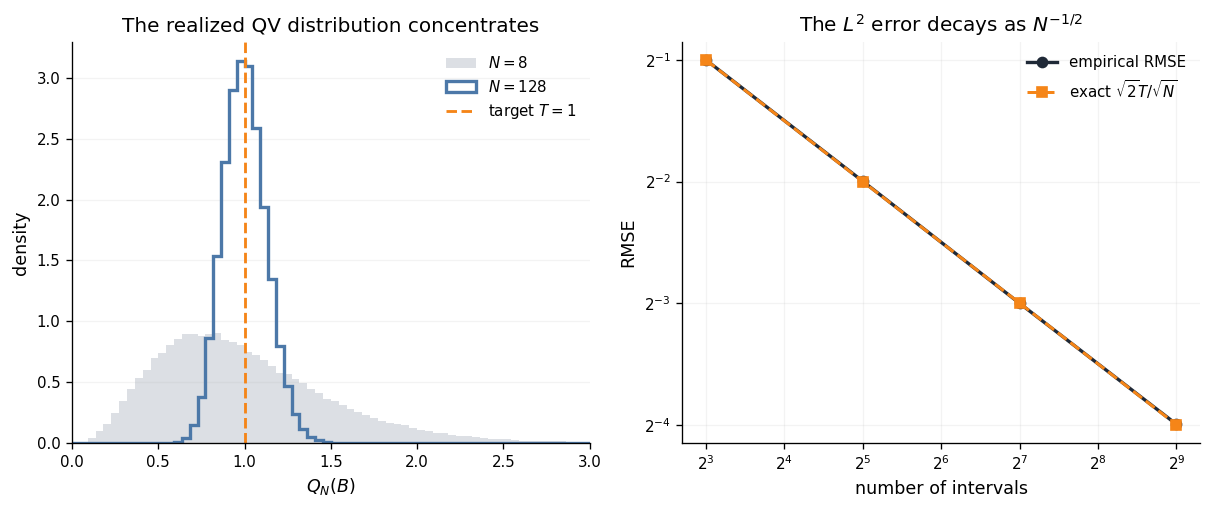

In [2]:
rng = np.random.default_rng(SEED + 1)
T = 1.0
n_mc = 120_000
partition_sizes = np.array([8, 32, 128, 512])

qv_samples = {
    N: (T / N) * rng.chisquare(N, size=n_mc)
    for N in partition_sizes
}
empirical_means = np.array([qv_samples[N].mean() for N in partition_sizes])
empirical_rmse = np.array([
    np.sqrt(np.mean((qv_samples[N] - T) ** 2))
    for N in partition_sizes
])
exact_rmse = np.sqrt(2.0) * T / np.sqrt(partition_sizes)
relative_rmse_error = np.max(np.abs(empirical_rmse / exact_rmse - 1.0))

print(" N      empirical mean      empirical RMSE      exact RMSE")
for N, mean, rmse, benchmark in zip(
    partition_sizes,
    empirical_means,
    empirical_rmse,
    exact_rmse,
):
    print(f"{N:>3d}         {mean:>9.6f}           {rmse:>9.6f}       {benchmark:>9.6f}")
print(f"Largest relative RMSE discrepancy: {relative_rmse_error:.3%}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

hist_bins = np.linspace(0.0, 4.5, 100)
axes[0].hist(
    qv_samples[8],
    bins=hist_bins,
    density=True,
    color=LIGHT_GREY,
    alpha=0.75,
    label=r"$N=8$",
)
axes[0].hist(
    qv_samples[128],
    bins=hist_bins,
    density=True,
    histtype="step",
    color=BLUE,
    linewidth=2.0,
    label=r"$N=128$",
)
axes[0].axvline(T, color=ORANGE, linestyle="--", linewidth=1.7, label=r"target $T=1$")
axes[0].set_xlim(0.0, 3.0)
axes[0].set_title("The realized QV distribution concentrates")
axes[0].set_xlabel(r"$Q_N(B)$")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.14)

axes[1].plot(
    partition_sizes,
    empirical_rmse,
    marker="o",
    color=INK,
    linewidth=2.0,
    label="empirical RMSE",
)
axes[1].plot(
    partition_sizes,
    exact_rmse,
    marker="s",
    linestyle="--",
    color=ORANGE,
    linewidth=1.8,
    label=r"exact $\sqrt{2}T/\sqrt{N}$",
)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log", base=2)
axes[1].set_title(r"The $L^2$ error decays as $N^{-1/2}$")
axes[1].set_xlabel("number of intervals")
axes[1].set_ylabel("RMSE")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> Monte Carlo draws from the exact uniform-partition law of $Q_N(B)$ and its $L^2$ error relative to $T=1$, using $120{,}000$ draws for each $N$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Refining the partition narrows the distribution around one. The empirical RMSE follows the exact $N^{-1/2}$ benchmark. The $L^2$ calculation above supplies the convergence proof, while the simulation reproduces its rate.</p>

## 2. Brownian motion has finite quadratic variation and infinite total variation

On the same partition, define the realized total variation

$$
V_P(B)=\sum_{i=1}^N|B_{t_i}-B_{t_{i-1}}|.
$$

Brownian motion has infinite total variation on every non-trivial time interval almost surely, while

$$
\langle B\rangle_T=T.
$$

For a uniform partition, each increment has distribution $N(0,T/N)$, so the expected realized total variation is

$$
E[V_N(B)]
=N\,E|B_{T/N}|
=\sqrt{\frac{2TN}{\pi}}.
$$

Thus first powers of the increments accumulate at order $\sqrt N$, whereas their squares remain at order one. This is the roughness that separates Brownian motion from finite-variation paths.

Terminal Brownian value: 2.270907
Finest-grid realized QV: 1.011166 (target 1.000000)
Finest-grid realized TV: 144.725427


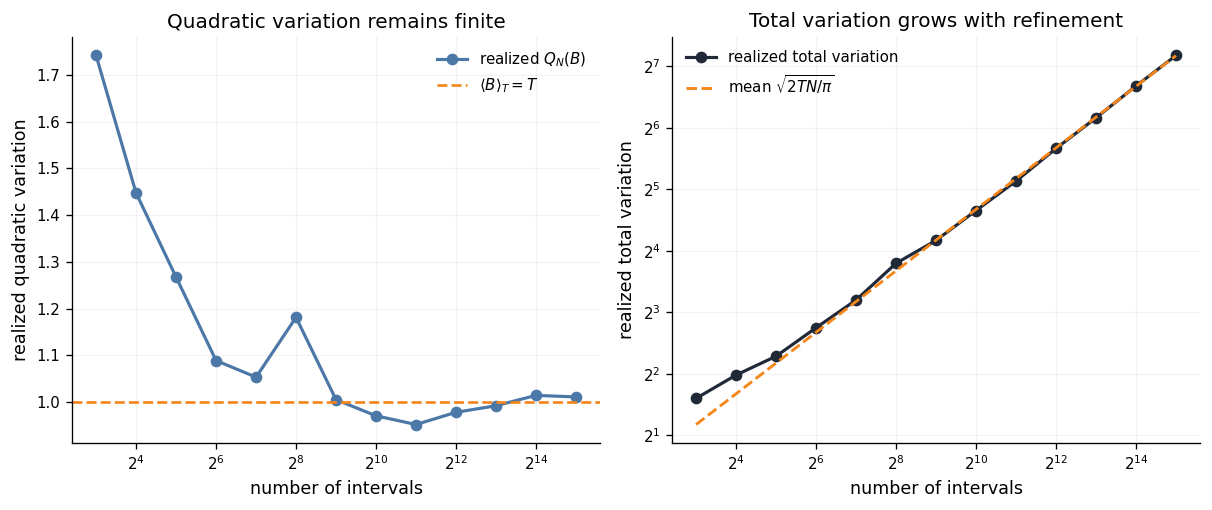

In [3]:
rng = np.random.default_rng(SEED + 2)
fine_level = 15
fine_intervals = 2**fine_level
dt = T / fine_intervals

brownian_increments = np.sqrt(dt) * rng.standard_normal(fine_intervals)
brownian_path = np.concatenate([[0.0], np.cumsum(brownian_increments)])
brownian_time = np.linspace(0.0, T, fine_intervals + 1)

levels = np.arange(3, fine_level + 1)
interval_counts = 2**levels
path_qv = np.array([
    np.sum(coarse_increments(brownian_increments, level) ** 2)
    for level in levels
])
path_tv = np.array([
    np.sum(np.abs(coarse_increments(brownian_increments, level)))
    for level in levels
])
expected_tv = np.sqrt(2.0 * T * interval_counts / np.pi)

print(f"Terminal Brownian value: {brownian_path[-1]:.6f}")
print(f"Finest-grid realized QV: {path_qv[-1]:.6f} (target {T:.6f})")
print(f"Finest-grid realized TV: {path_tv[-1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(
    interval_counts,
    path_qv,
    marker="o",
    color=BLUE,
    linewidth=1.9,
    label=r"realized $Q_N(B)$",
)
axes[0].axhline(T, color=ORANGE, linestyle="--", linewidth=1.6, label=r"$\langle B\rangle_T=T$")
axes[0].set_xscale("log", base=2)
axes[0].set_title("Quadratic variation remains finite")
axes[0].set_xlabel("number of intervals")
axes[0].set_ylabel("realized quadratic variation")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(
    interval_counts,
    path_tv,
    marker="o",
    color=INK,
    linewidth=1.9,
    label="realized total variation",
)
axes[1].plot(
    interval_counts,
    expected_tv,
    linestyle="--",
    color=ORANGE,
    linewidth=1.7,
    label=r"mean $\sqrt{2TN/\pi}$",
)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log", base=2)
axes[1].set_title("Total variation grows with refinement")
axes[1].set_xlabel("number of intervals")
axes[1].set_ylabel("realized total variation")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 2.</strong> Realized quadratic and total variation of one Brownian path on nested dyadic partitions of $[0,1]$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The left panel fluctuates around the finite limit one, while the right panel grows on the same path at approximately the $\sqrt N$ scale predicted by its expectation. One family of increments therefore supports two different limiting geometries.</p>

## 3. Continuous finite-variation perturbations disappear

Let $A$ be a continuous finite-variation function and set $X=B+A$. On every partition,

$$
Q_P(X)
=Q_P(B)
+2\sum_i\Delta B_i\Delta A_i
+Q_P(A).
$$

If $\operatorname{TV}(A;[0,T])<\infty$, then

$$
Q_P(A)
\leq\max_i|\Delta A_i|\sum_i|\Delta A_i|
\longrightarrow0.
$$

The cross term vanishes by Cauchy-Schwarz:

$$
\left|\sum_i\Delta B_i\Delta A_i\right|
\leq\sqrt{Q_P(B)Q_P(A)}\xrightarrow{P}0.
$$

Consequently,

$$
\langle B+A\rangle_T=\langle B\rangle_T=T.
$$

Quadratic variation is insensitive to continuous finite-variation drift because only the Brownian-scale increments survive after squaring and summing.

Finest-grid QV of finite-variation part: 0.00087233
Finest-grid doubled cross term:          0.00052321
Finest-grid QV difference Q(X)-Q(B):     0.00139554


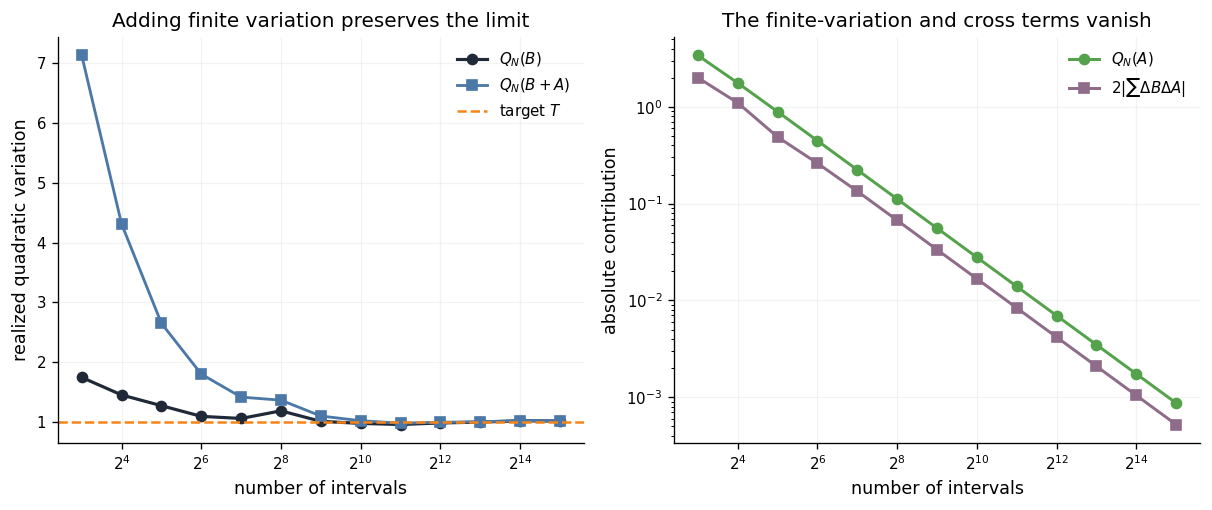

In [4]:
finite_variation_path = (
    1.2 * np.sin(2.0 * np.pi * brownian_time)
    + 0.4 * brownian_time
)
finite_variation_increments = np.diff(finite_variation_path)
perturbed_increments = brownian_increments + finite_variation_increments

qv_brownian = path_qv.copy()
qv_perturbed = np.array([
    np.sum(coarse_increments(perturbed_increments, level) ** 2)
    for level in levels
])
qv_finite_variation = np.array([
    np.sum(coarse_increments(finite_variation_increments, level) ** 2)
    for level in levels
])
twice_cross_term = np.array([
    2.0 * np.sum(
        coarse_increments(brownian_increments, level)
        * coarse_increments(finite_variation_increments, level)
    )
    for level in levels
])

print(f"Finest-grid QV of finite-variation part: {qv_finite_variation[-1]:.8f}")
print(f"Finest-grid doubled cross term:          {twice_cross_term[-1]:.8f}")
print(f"Finest-grid QV difference Q(X)-Q(B):     {(qv_perturbed[-1] - qv_brownian[-1]):.8f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(
    interval_counts,
    qv_brownian,
    marker="o",
    color=INK,
    linewidth=1.9,
    label=r"$Q_N(B)$",
)
axes[0].plot(
    interval_counts,
    qv_perturbed,
    marker="s",
    color=BLUE,
    linewidth=1.7,
    label=r"$Q_N(B+A)$",
)
axes[0].axhline(T, color=ORANGE, linestyle="--", linewidth=1.5, label=r"target $T$")
axes[0].set_xscale("log", base=2)
axes[0].set_title("Adding finite variation preserves the limit")
axes[0].set_xlabel("number of intervals")
axes[0].set_ylabel("realized quadratic variation")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(
    interval_counts,
    qv_finite_variation,
    marker="o",
    color=GREEN,
    linewidth=1.8,
    label=r"$Q_N(A)$",
)
axes[1].plot(
    interval_counts,
    np.abs(twice_cross_term),
    marker="s",
    color=PURPLE,
    linewidth=1.8,
    label=r"$2|\sum\Delta B\Delta A|$",
)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log", base=10)
axes[1].set_title("The finite-variation and cross terms vanish")
axes[1].set_xlabel("number of intervals")
axes[1].set_ylabel("absolute contribution")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Realized quadratic variation of $B$ and $B+A$ for $A_t=1.2\sin(2\pi t)+0.4t$, together with the two additional terms in the partition identity.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The two quadratic-variation curves merge as the grid is refined. The right panel identifies the mechanism: both the squared finite-variation increments and their cross contribution with Brownian increments shrink toward zero.</p>

## 4. A standard process accumulates local variance

In the course notation, a standard process has the form

$$
X_t=X_0+\int_0^t a_s\,ds+\int_0^t b_s\,dB_s,
$$

where $a$ and $b$ are adapted and, for every finite $T$,

$$
\int_0^T|a_s|\,ds<\infty,
\qquad
\int_0^T|b_s|^2\,ds<\infty
$$

almost surely. Theorem 5.15 gives

$$
\langle X\rangle_t=\int_0^t|b_s|^2\,ds.
$$

The drift integral has zero quadratic variation, while $b_t^2$ is the instantaneous rate at which quadratic variation accumulates. For the experiment below,

$$
a(t)=0.4\cos(2\pi t),
\qquad
b(t)=0.7+0.45\sin(2\pi t),
$$

so

$$
\langle X\rangle_1=\int_0^1 b(t)^2\,dt
=0.7^2+\frac{0.45^2}{2}=0.59125.
$$

Exact integrated variance at T: 0.591250
N=  64: terminal realized QV = 0.536570; error = -0.054680
N= 256: terminal realized QV = 0.554383; error = -0.036867
N=4096: terminal realized QV = 0.581608; error = -0.009642


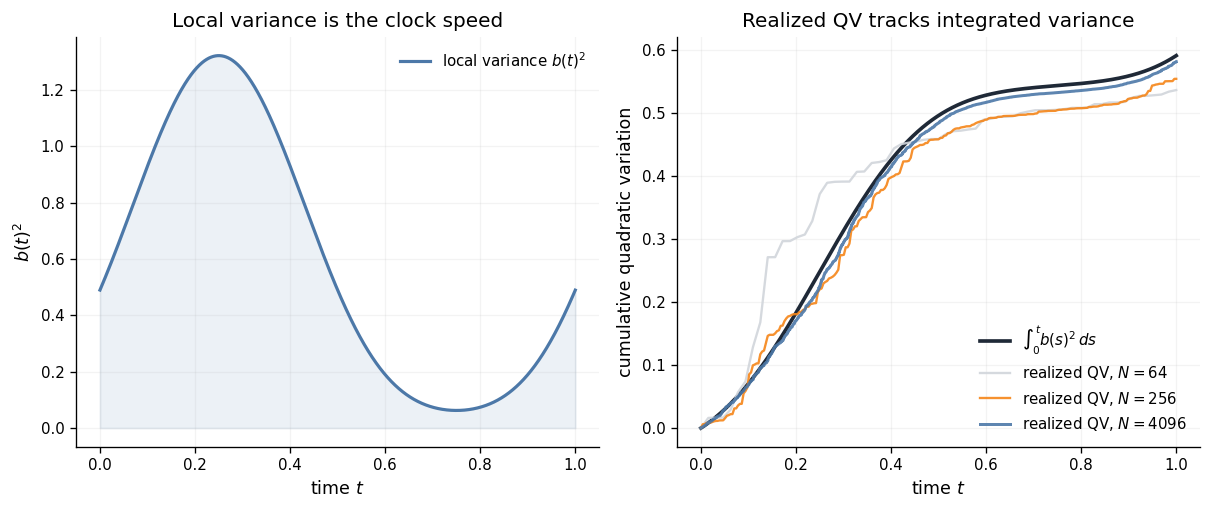

In [5]:
rng = np.random.default_rng(SEED + 3)
standard_level = 14
standard_intervals = 2**standard_level
standard_dt = T / standard_intervals
standard_time = np.linspace(0.0, T, standard_intervals + 1)
standard_left_time = standard_time[:-1]

drift_rate = 0.4 * np.cos(2.0 * np.pi * standard_left_time)
volatility = 0.7 + 0.45 * np.sin(2.0 * np.pi * standard_left_time)
standard_brownian_increments = np.sqrt(standard_dt) * rng.standard_normal(standard_intervals)
standard_process_increments = (
    drift_rate * standard_dt
    + volatility * standard_brownian_increments
)
standard_process = np.concatenate([[0.0], np.cumsum(standard_process_increments)])
integrated_variance = integrated_variance_curve(standard_time)

display_levels = [6, 8, 12]
realized_qv_curves = {}
terminal_qv = []
for level in display_levels:
    increments = coarse_increments(standard_process_increments, level)
    realized_qv_curves[level] = np.concatenate([[0.0], np.cumsum(increments**2)])
    terminal_qv.append(realized_qv_curves[level][-1])

exact_terminal_clock = integrated_variance[-1]
print(f"Exact integrated variance at T: {exact_terminal_clock:.6f}")
for level, value in zip(display_levels, terminal_qv):
    print(f"N={2**level:>4d}: terminal realized QV = {value:.6f}; error = {value - exact_terminal_clock:+.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(
    standard_left_time,
    volatility**2,
    color=BLUE,
    linewidth=1.9,
    label=r"local variance $b(t)^2$",
)
axes[0].fill_between(
    standard_left_time,
    0.0,
    volatility**2,
    color=BLUE,
    alpha=0.10,
)
axes[0].set_title("Local variance is the clock speed")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"$b(t)^2$")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(
    standard_time,
    integrated_variance,
    color=INK,
    linewidth=2.2,
    label=r"$\int_0^t b(s)^2\,ds$",
)
curve_colors = [LIGHT_GREY, ORANGE, BLUE]
for level, color in zip(display_levels, curve_colors):
    grid_time = np.linspace(0.0, T, 2**level + 1)
    axes[1].plot(
        grid_time,
        realized_qv_curves[level],
        color=color,
        linewidth=1.4 if level < display_levels[-1] else 1.8,
        alpha=0.9,
        label=rf"realized QV, $N={2**level}$",
    )
axes[1].set_title("Realized QV tracks integrated variance")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel("cumulative quadratic variation")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> Local variance and cumulative realized quadratic variation for a standard process with non-zero drift and deterministic time-varying volatility.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Where $b(t)^2$ is high, the theoretical clock grows more rapidly. Finer realized-QV curves follow this accumulated clock more closely, while the non-zero drift does not enter the target.</p>

## 5. Quadratic variation produces the Itô correction

For every partition of $[0,T]$, the algebraic identity

$$
B_T^2-B_0^2
=2\sum_{i=1}^N B_{t_{i-1}}(B_{t_i}-B_{t_{i-1}})
+\sum_{i=1}^N(B_{t_i}-B_{t_{i-1}})^2
$$

follows by telescoping $B_{t_i}^2-B_{t_{i-1}}^2$. As the mesh tends to zero, the first sum converges in probability to the Itô integral and the second converges in probability to $T$. Therefore

$$
B_T^2=2\int_0^T B_t\,dB_t+T,
$$

or, in stochastic differential notation,

$$
d(B_t^2)=2B_t\,dB_t+dt.
$$

The mnemonic $(dB_t)^2=dt$ records this quadratic-variation limit. The term $dt$ is the second-order contribution that survives in Itô's formula.

Target integral 0.5*(B_T^2-T): 2.078510
Finest left-point sum:          2.072927
Finest quadratic-variation term:1.011166
Maximum partition-identity residual: 1.288e-13


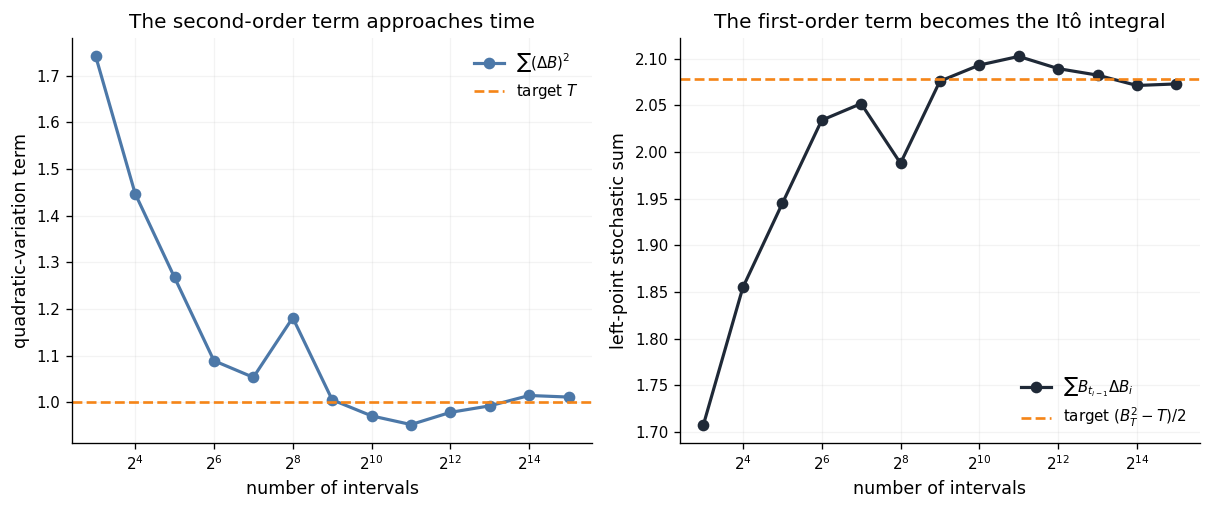

In [6]:
ito_left_sums = []
ito_qv_terms = []
partition_identity_residuals = []

for level in levels:
    block_size = 2 ** (fine_level - level)
    increments = coarse_increments(brownian_increments, level)
    left_values = brownian_path[::block_size][:-1]
    ito_left = np.sum(left_values * increments)
    qv_term = np.sum(increments**2)

    ito_left_sums.append(ito_left)
    ito_qv_terms.append(qv_term)
    partition_identity_residuals.append(
        2.0 * ito_left + qv_term - brownian_path[-1] ** 2
    )

ito_left_sums = np.asarray(ito_left_sums)
ito_qv_terms = np.asarray(ito_qv_terms)
partition_identity_residuals = np.asarray(partition_identity_residuals)
ito_target = 0.5 * (brownian_path[-1] ** 2 - T)

print(f"Target integral 0.5*(B_T^2-T): {ito_target:.6f}")
print(f"Finest left-point sum:          {ito_left_sums[-1]:.6f}")
print(f"Finest quadratic-variation term:{ito_qv_terms[-1]:.6f}")
print(f"Maximum partition-identity residual: {np.max(np.abs(partition_identity_residuals)):.3e}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(
    interval_counts,
    ito_qv_terms,
    marker="o",
    color=BLUE,
    linewidth=1.9,
    label=r"$\sum(\Delta B)^2$",
)
axes[0].axhline(T, color=ORANGE, linestyle="--", linewidth=1.6, label=r"target $T$")
axes[0].set_xscale("log", base=2)
axes[0].set_title("The second-order term approaches time")
axes[0].set_xlabel("number of intervals")
axes[0].set_ylabel("quadratic-variation term")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(
    interval_counts,
    ito_left_sums,
    marker="o",
    color=INK,
    linewidth=1.9,
    label=r"$\sum B_{t_{i-1}}\Delta B_i$",
)
axes[1].axhline(
    ito_target,
    color=ORANGE,
    linestyle="--",
    linewidth=1.6,
    label=r"target $(B_T^2-T)/2$",
)
axes[1].set_xscale("log", base=2)
axes[1].set_title("The first-order term becomes the Itô integral")
axes[1].set_xlabel("number of intervals")
axes[1].set_ylabel("left-point stochastic sum")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> The two terms in the exact partition identity for $B_T^2$, evaluated on nested dyadic partitions of the Brownian path from Figure 2.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The quadratic term approaches $T$, while the left-point sum approaches $(B_T^2-T)/2$. Their finite-partition identity already adds to $B_T^2$ up to floating-point error; the limits produce the Itô correction.</p>

## References

- *MATH3015: Stochastic Processes*, Chapter 5, Theorem 5.1, Definitions 5.13-5.14, Theorem 5.15, and Lemma 5.16.
- Fima C. Klebaner, *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 4, Theorem 4.9, Corollary 4.10, and equation (4.42).